**Predicting Solar Energy Production Using Machine Learning**

**Importing Python Libraries**

In [ ]:
import pandas as pd  #for handling data in DataFrame format
import matplotlib.pyplot as plt    #for creating visualizations
from sklearn.model_selection import train_test_split  #for splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler  #for standardizing feature values
from sklearn.linear_model import LinearRegression  #Linear regression model
from sklearn.tree import DecisionTreeRegressor  #decision tree regression model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  #Random Forest and Gradient Boosting regression models
from sklearn.svm import SVR  #Support Vector Regression model
from sklearn.neural_network import MLPRegressor  #Multi-layer Perceptron (Neural Network) regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Regression evaluation metrics
from sklearn.model_selection import cross_val_score  #for cross-validation to assess the performance of ML model

**Loading** **Dataset**

In [ ]:
data = pd.read_csv('Solar Power Plant Data.csv')

**Pre-Processing**

In [ ]:
#Displaying information about the dataset
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [ ]:
#Displaying the first few rows of the dataset to get an overview of the data
data.head()


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [ ]:
#Displaying the column names of the dataset
data.columns

Index(['Date-Hour(NMT)', 'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation',
       'AirTemperature', 'RelativeAirHumidity', 'SystemProduction'],
      dtype='object')

In [ ]:
#Defining the features (independent variables) for the prediction model
X = data[['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature', 'RelativeAirHumidity']]

#Defining the target variable (dependent variable) for the prediction model
y = data['SystemProduction']


**Splitting dataset into Training & Test sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling**

In [ ]:
#Standardizing the feature variables to have zero mean and unit variance
scaler = StandardScaler()

#Applying standardization to the training set
X_train = scaler.fit_transform(X_train)

#Applying the same standardization to the testing set
X_test = scaler.transform(X_test)


**Initializing Regression Models**

In [ ]:
models = {
    'Linear Regression': LinearRegression(),                  #Linear regression model
    'Decision Tree': DecisionTreeRegressor(),                 #Decision tree regression model
    'Random Forest': RandomForestRegressor(),                 #Random Forest regression model
    'Gradient Boosting': GradientBoostingRegressor(),         #Gradient Boosting regression model
    'Support Vector Machine': SVR(),                          #Support Vector Regression model
    'Neural Network': MLPRegressor(max_iter=100)              #Multi-layer Perceptron (Neural Network) regression model
}

**Training & Evaluating Models**

Model: Linear Regression
Mean Absolute Error: 461.70254847890834
Mean Squared Error: 767116.7300091356
R-squared Value: 0.6122642021271074
--------------------------

Model: Decision Tree
Mean Absolute Error: 413.97835633561647
Mean Squared Error: 989761.1883783975
R-squared Value: 0.49972953389381813
--------------------------

Model: Random Forest
Mean Absolute Error: 331.37268708082195
Mean Squared Error: 553572.1625939065
R-squared Value: 0.7201993702561866
--------------------------

Model: Gradient Boosting
Mean Absolute Error: 358.14527778445404
Mean Squared Error: 621940.543790031
R-squared Value: 0.6856428708404567
--------------------------

Model: Support Vector Machine
Mean Absolute Error: 582.6889804553306
Mean Squared Error: 1954692.1865379314
R-squared Value: 0.012009378893133915
--------------------------



/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Model: Neural Network
Mean Absolute Error: 441.4819823767179
Mean Squared Error: 788976.7324407989
R-squared Value: 0.6012151594550184
--------------------------



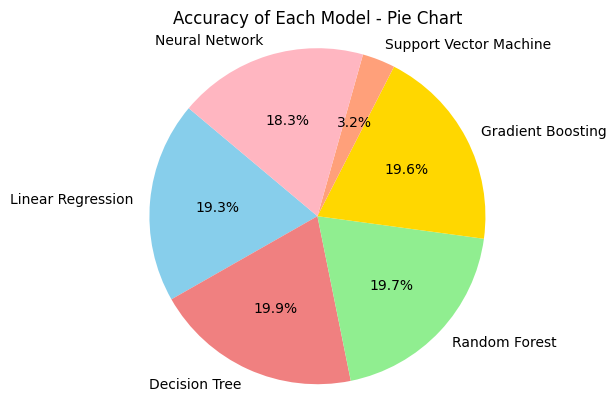

In [ ]:
# List to store accuracy values for each model
accuracy_list = []

# Training and evaluating each regression model
for name, model in models.items():
    # Training the model using the training set
    model.fit(X_train, y_train)

    # Making predictions on the test set
    predictions = model.predict(X_test)

    # Calculating accuracy based on the proportion of correct predictions
    correct_predictions = sum((predictions >= 0) & (predictions <= 100))
    total_predictions = len(predictions)
    accuracy = (correct_predictions / total_predictions) * 100
    accuracy_list.append(accuracy)

    # Print evaluation metrics for the current model
    print(f"Model: {name}")
    print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions)}")
    print(f"Mean Squared Error: {mean_squared_error(y_test, predictions)}")
    print(f"R-squared Value: {r2_score(y_test, predictions)}")
    print("--------------------------\n")

# Pie Chart for Accuracy based on the proportion of correct predictions
plt.pie(accuracy_list, labels=models.keys(), autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightsalmon', 'lightpink'])
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Accuracy of Each Model - Pie Chart")
plt.show()

**Making Predictions & Displaying Results**

In [ ]:
#Making predictions for each model
for name, model in models.items():
    #Training the model using the training set
    model.fit(X_train, y_train)

    # =Making predictions on the test set
    predictions = model.predict(X_test)

    #Display the model name and its corresponding predictions
    print(f"Model: {name}")
    print("Predictions:", predictions)
    print("--------------------------\n")


Model: Linear Regression
Predictions: [ 434.1912624  2815.15033141 1685.7154249  ...   42.7365833    88.69453798
 1453.10613291]
--------------------------

Model: Decision Tree
Predictions: [  42.25   1419.6667 1031.3333 ...    0.        0.     1843.8333]
--------------------------

Model: Random Forest
Predictions: [ 376.754166 2091.145009 1621.61165  ...    0.          4.826669
 1201.086656]
--------------------------

Model: Gradient Boosting
Predictions: [4.09846972e+02 2.82063956e+03 1.41837411e+03 ... 1.07056683e+01
 1.30379486e+00 1.02509890e+03]
--------------------------

Model: Support Vector Machine
Predictions: [ 40.90406171 487.41778611 265.71965729 ...   7.75694103   3.5288378
 226.36932937]
--------------------------

Model: Neural Network
Predictions: [ 111.10054216 2231.63941029 1112.21271107 ...   33.14948473  -26.54755132
 1211.75244271]
--------------------------



/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**Cross-Validation**

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    print(f"\nCross-Validation Scores for {name}: {scores}")


Cross-Validation Scores for Linear Regression: [-348.88577653 -844.70547841 -691.72334434 -467.60392287 -190.12095588]

Cross-Validation Scores for Decision Tree: [-170.21855942 -888.33323476 -994.29584886 -562.33345034 -100.61486866]

Cross-Validation Scores for Random Forest: [-139.10986075 -797.52092088 -752.16306466 -455.93106416  -71.97913833]

Cross-Validation Scores for Gradient Boosting: [-145.29958507 -793.73998404 -823.43421343 -464.79930639  -89.0913956 ]

Cross-Validation Scores for Support Vector Machine: [ -156.10140602  -820.18971656 -1395.99559471  -754.05915602
   -67.1303308 ]


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Cross-Validation Scores for Neural Network: [-226.80248925 -819.15800528 -715.26573014 -465.47029776 -152.77690478]


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**Hyperparameter Tuning**

In [ ]:
#Hyperparameter Tuning (Random Forest as an example for lesser Mean Absolute Error)
from sklearn.model_selection import RandomizedSearchCV

#Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
#Initialize the Random Forest model
rf_model = RandomForestRegressor()

#Initializing RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, n_iter=10, cv=5, scoring='neg_mean_absolute_error', random_state=42)

#Fitting the RandomizedSearchCV
rf_random.fit(X, y)

#Displaying the best parameters
print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


**Visualization**

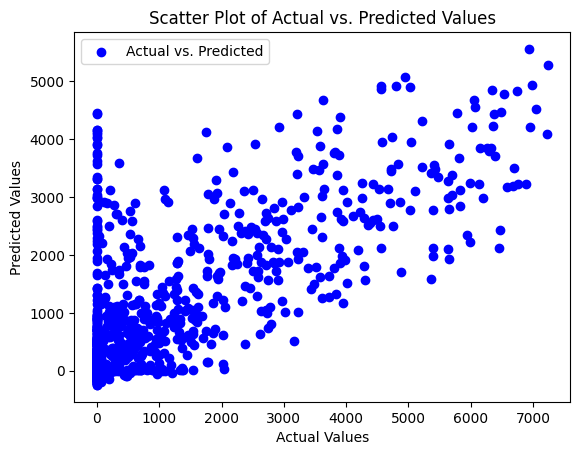

In [ ]:
#Scatter plot of actual vs. predicted values (Random Forest as an example for lesser Mean Absolute Error)
plt.scatter(y_test, predictions, color='blue', label='Actual vs. Predicted')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scatter Plot of Actual vs. Predicted Values")
plt.legend()
plt.show()

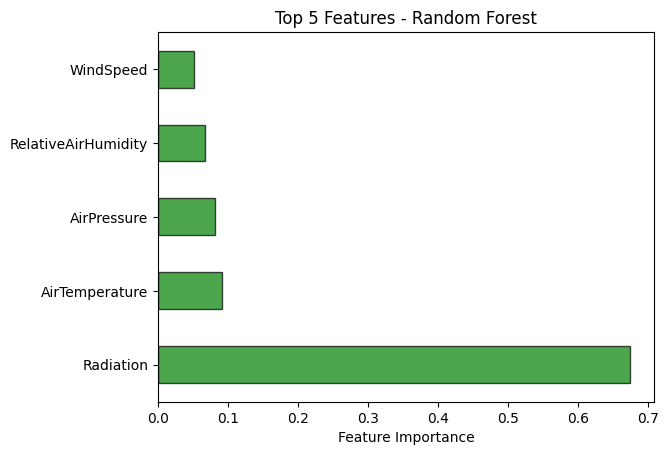

In [ ]:
# Feature Importance plot (Random Forest as an example for lesser Mean Absolute Error)
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    feature_importances.nlargest(5).plot(kind='barh', color='green', alpha=0.7, edgecolor='black')
    plt.xlabel("Feature Importance")
    plt.title("Top 5 Features - Random Forest")
    plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

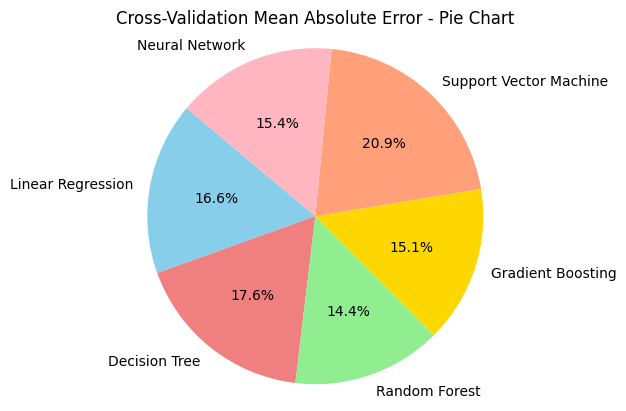

In [ ]:
# Cross-Validation Scores Pie Chart
scores_dict = {name: -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean() for name, model in models.items()}

plt.pie(scores_dict.values(), labels=scores_dict.keys(), autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightsalmon', 'lightpink'])
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Cross-Validation Mean Absolute Error - Pie Chart")
plt.show()
